## Imports & Loads

In [1]:
CANVAS_SIZE = (150, 95) # mm

In [2]:
import numpy as np
from PIL import Image, ImageOps

# Ensure CANVAS_SIZE is defined globally or imported, e.g., CANVAS_SIZE = (440, 440)

def resize_image(img: object):
    """
    Unified entry point that pads and resizes either a PIL Image 
    or a NumPy ndarray to CANVAS_SIZE while preserving aspect ratio.
    """
    if isinstance(img, np.ndarray):
        # Route to the ndarray processor
        return resize_image_ndarray(img)
    else:
        # Original PIL logic
        if len(img.getbands()) == 1:
            PADDING_COLOR = 0  # Single integer for grayscale/depth maps
        else:
            PADDING_COLOR = (0, 0, 0)  # Tuple for RGB images
        return ImageOps.pad(img, CANVAS_SIZE, color=PADDING_COLOR)

def resize_image_ndarray(image_array: np.ndarray) -> np.ndarray:
    """
    Pads and resizes a NumPy ndarray to CANVAS_SIZE while maintaining aspect ratio.
    Automatically handles arbitrary channels (Grayscale, RGB, BGR, or multi-band masks).
    """
    # 1. Determine padding color based on array shape
    if image_array.ndim == 2:
        # Grayscale / Single-channel mask
        PADDING_COLOR = 0
    else:
        # Multi-channel image (RGB, BGR, etc.)
        channels = image_array.shape[2]
        PADDING_COLOR = (0,) * channels

    # 2. Convert NumPy array to PIL Image
    if image_array.dtype == bool:
        pil_img = Image.fromarray(image_array.astype(np.uint8) * 255)
    elif np.issubdtype(image_array.dtype, np.floating):
        # Scale float [0, 1] up to integer [0, 255]
        pil_img = Image.fromarray((image_array * 255).astype(np.uint8))
    else:
        pil_img = Image.fromarray(image_array)

    # 3. Use ImageOps.pad to handle aspect ratio centering and padding
    padded_pil = ImageOps.pad(pil_img, CANVAS_SIZE, color=PADDING_COLOR)

    # 4. Convert back to a NumPy array
    output_array = np.array(padded_pil)
    
    # Restore boolean type if the input was a mask
    if image_array.dtype == bool:
        return output_array > 127
        
    return output_array

In [3]:
import os
import matplotlib.pyplot as plt

In [4]:
from transformers import pipeline

depth_estimator = pipeline(
    "depth-estimation",
    model="Intel/dpt-hybrid-midas",
    api_key=os.environ["HF_TOKEN"]
)

Loading weights:   0%|          | 0/414 [00:00<?, ?it/s]

## Image Pre-loading

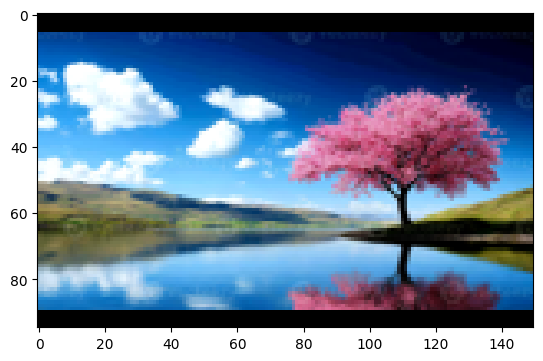

In [5]:
import numpy as np
from PIL import Image, ImageOps, ImageFilter, ImageEnhance
from skimage.segmentation import slic
import matplotlib.pyplot as plt


# 1. Load your PIL image
pil_original_image = Image.open("C:/Users/Simon/Documents/projecten/paint-bot/images/pink-tree.jpeg")
enhancer = ImageEnhance.Contrast(pil_original_image)
contrast_factor = 1.2
pil_original_image = enhancer.enhance(contrast_factor)

# 2. Resize to 440x440 (assuming resize_image is defined elsewhere)
pil_resized_image = resize_image(pil_original_image)

# GaussianBlur takes a 'radius' parameter. Higher radius = more blur.
pil_blurred_image = pil_resized_image.filter(ImageFilter.GaussianBlur(radius=5))
np_resized_blurred_image = np.array(pil_blurred_image)

# 3. Convert the original resized PIL image to a NumPy array (if still needed)
np_resized_image = np.array(pil_resized_image)
np_original_image = np.array(pil_original_image)

# Display the blurred image to verify
plt.imshow(np_resized_image)
plt.show()

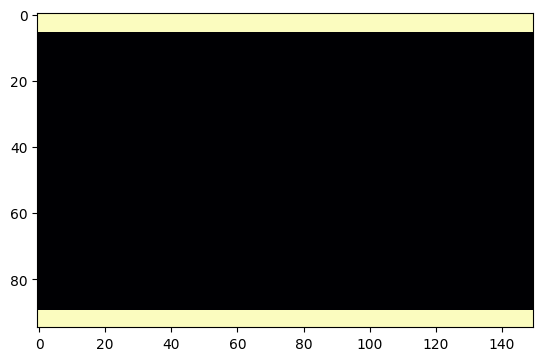

In [6]:
# 3. Create a "dummy" pure white image of the exact same original size
# This represents our "real pixels" mask BEFORE padding
mask_canvas = Image.new("L", pil_original_image.size, color=255)

# 4. Apply the exact same padding transformation to the mask canvas
# ImageOps.pad will scale and pad this mask identically to the elephant image
padded_mask_resized = ImageOps.pad(mask_canvas, CANVAS_SIZE, color=0)
np_padded_mask_resized = np.array(padded_mask_resized)

# 5. Convert mask to a 1 and 0 NumPy array
# Wherever the padded_mask is 255 (white), it's a real pixel (1). Otherwise, it's 0.
padding_mask = (np.array(padded_mask_resized) == 0).astype(np.uint8)
plt.imshow(padding_mask, cmap='magma')
plt.show()

## Depth map

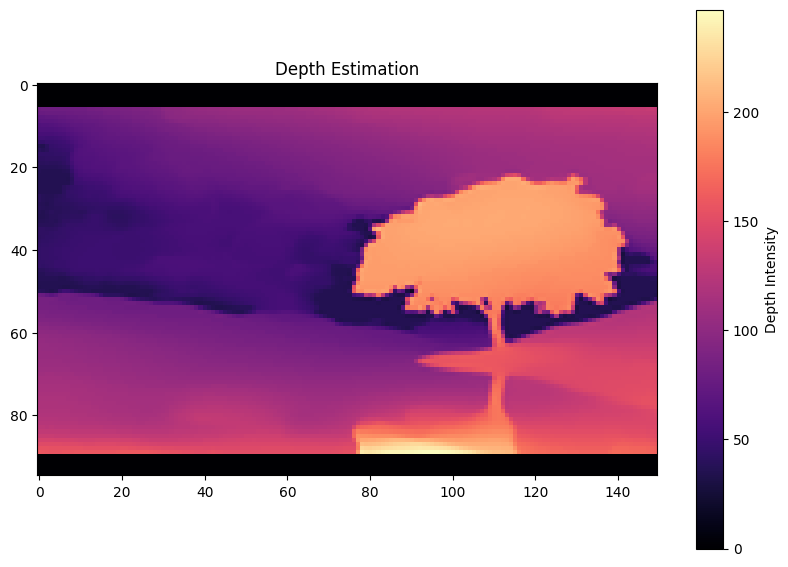

In [7]:
# Pass the original PIL image to the depth estimator
# depth_estimator()
depth_prediction = depth_estimator(pil_original_image)
# depth_map_pil = np.zeros(tuple(np_original_image.shape[:2]), dtype=np.uint8) # depth_estimator(pil_original_image)
# Extract the depth map as a numpy array
depth_map_pil = depth_prediction["depth"]
resized_depth_map = np.array(resize_image ( depth_map_pil) )

fig, ax1 = plt.subplots(1, 1, figsize=(10, 7)) # Adjusted 20x7 to 10x7 so a single plot isn't stretched too wide
ax1.set_title("Depth Estimation")
im = ax1.imshow(resized_depth_map, cmap="magma")
fig.colorbar(im, ax=ax1, label="Depth Intensity")
plt.show()

## Segmentation

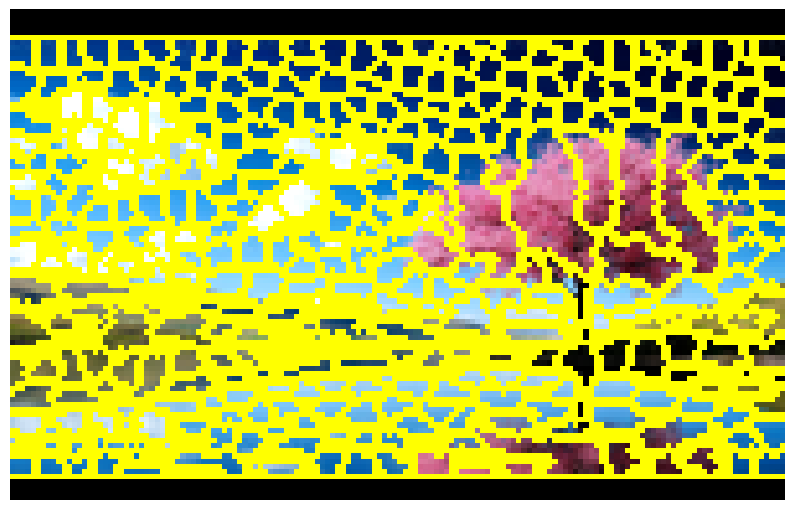

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass
from skimage.segmentation import mark_boundaries
from PIL import Image

# 1. Run SLIC on the original image as you did
# 1. Run SLIC on the original image as you did
segments = slic(
    np_original_image,
    n_segments=500,
    compactness=10
)

# 2. Cast to int32 so PIL can handle it, then resize using Nearest Neighbor
segments_int32 = segments.astype(np.int32) # <--- Added this line
segments_pil = Image.fromarray(segments_int32)

resized_segments_pil = ImageOps.pad(
    segments_pil, 
    CANVAS_SIZE, 
    method=Image.Resampling.NEAREST, 
    color=0
)
resized_segments = np.array(resized_segments_pil)


# 3. Calculate centroids on the NEW resized segments
for label in np.unique(resized_segments):
    # Mask out the background padding (label 0 might contain padding now)
    if label == 0: 
        continue
    centroid = center_of_mass(resized_segments == label)

# 4. Plot using the ALREADY resized/padded elephant image from your previous step
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.imshow(mark_boundaries(np_resized_image, resized_segments)) # 'image' is your 440x440 padded np array
# ax.setTitle("1. Resized SLIC Superpixel Segments", fontsize=14, fontweight='bold')
ax.axis("off")
plt.show()

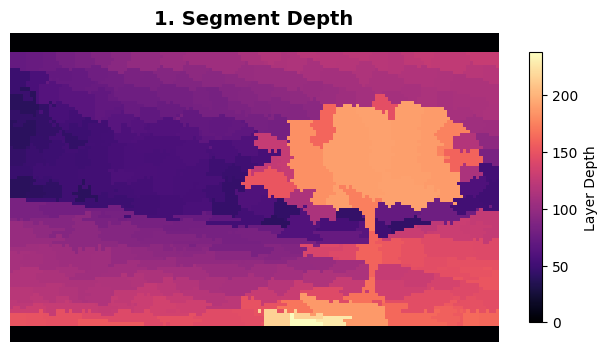

In [9]:
binned_depth_visualization = np.zeros_like(resized_segments, dtype=np.float32)

segment_labels = np.unique(segments)
segment_depths = []

for label in segment_labels:
    mask = (resized_segments == label)

    mean_depth = resized_depth_map[mask].mean()
    
    # Fill the entire segment region with its average depth value
    binned_depth_visualization[mask] = mean_depth

    segment_depths.append((label, mean_depth))

segment_depths.sort(key=lambda x: x[1], reverse=False) # sort segments

fig, ax = plt.subplots(1, 1)

im2 = ax.imshow(binned_depth_visualization, cmap="magma")
ax.set_title("1. Segment Depth", fontsize=14, fontweight='bold')
ax.axis("off")
fig.colorbar(im2, ax=ax, shrink=0.6, label="Layer Depth")

plt.tight_layout()
plt.show()

## Saliency

In [10]:
from saliency import generate_clean_saliency

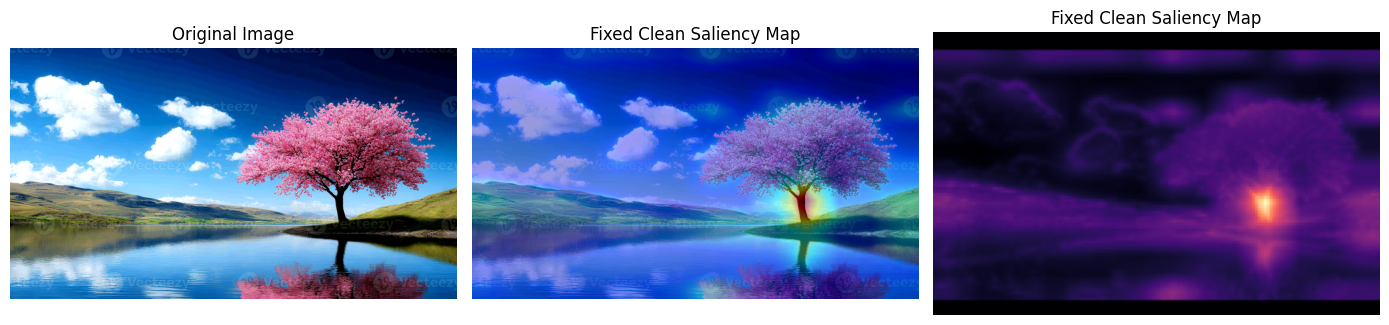

In [11]:
import cv2
import matplotlib.pyplot as plt

blurred_saliency, img_cv = generate_clean_saliency(pil_original_image)

resized_blurred_saliency = resize_image(np.array(blurred_saliency))

# Color map generation
heatmap_color = cv2.applyColorMap(blurred_saliency, cv2.COLORMAP_JET)

# Overlay with original image
output_img = cv2.addWeighted(img_cv, 0.6, heatmap_color, 0.4, 0)
output_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)

# ==========================================
# 3. DISPLAY RESULTS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(14, 7))
axes[0].imshow(pil_original_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(output_img)
axes[1].set_title("Fixed Clean Saliency Map")
axes[1].axis("off")

axes[2].imshow(resized_blurred_saliency, cmap="magma")
axes[2].set_title("Fixed Clean Saliency Map")
axes[2].axis("off")

plt.tight_layout()
plt.show()

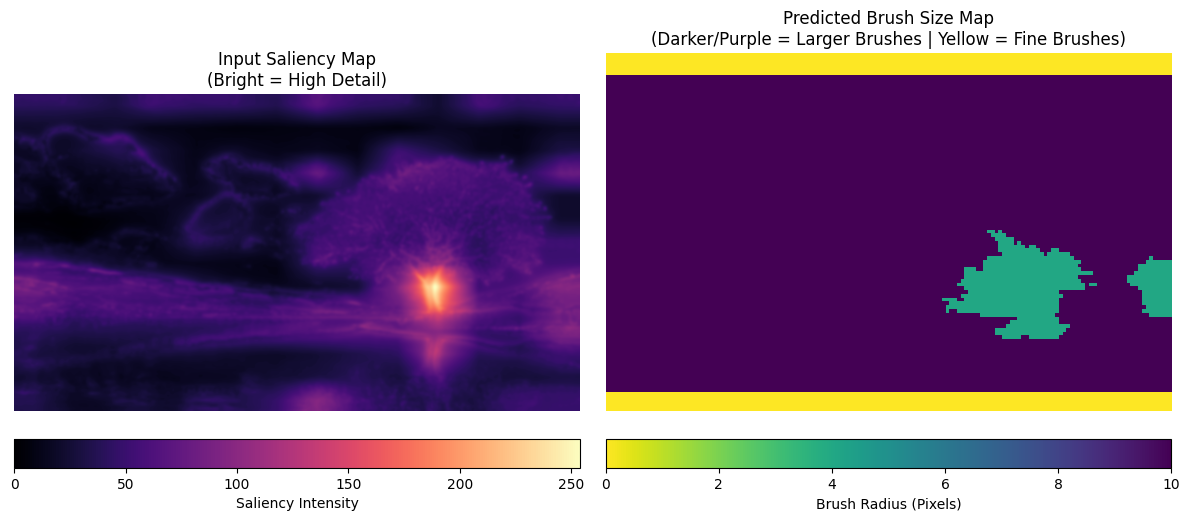

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize an empty map for brush size visualization
brush_size_map = np.zeros_like(resized_segments, dtype=np.float32)

# Define configuration limits (must match your loop settings)
# max_brush = 20
# min_brush = 1

# 2. Pre-calculate and populate the brush size map per segment
for label, mean_depth in segment_depths:
    segment_mask = (resized_segments == label)
    if not np.any(segment_mask):
        continue
    
    # Calculate mean saliency (assumes 0-255 scale)
    mean_saliency = np.mean(resized_blurred_saliency[segment_mask])
    
    # Map saliency to brush size
    if mean_saliency >= 80:
        brush_size_map[segment_mask] = 4
    else:
        brush_size_map[segment_mask] = 10

    # normalized_saliency = mean_saliency / 255.0
    # dynamic_brush = max_brush - (normalized_saliency * (max_brush - min_brush))
    # clipped_brush = int(np.clip(dynamic_brush, min_brush, max_brush))
    
    # Assign the brush size value to the entire segment area

# 3. Plot the visualization side-by-side with the Saliency Map
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the saliency input for reference
im1 = axes[0].imshow(blurred_saliency, cmap="magma")
axes[0].set_title("Input Saliency Map\n(Bright = High Detail)")
axes[0].axis("off")
fig.colorbar(im1, ax=axes[0], orientation='horizontal', pad=0.05, label="Saliency Intensity")

# Plot the computed brush sizes
# Using 'viridis_r' (reversed) so smaller values (fine details) stand out distinctly
im2 = axes[1].imshow(brush_size_map, cmap="viridis_r")
axes[1].set_title("Predicted Brush Size Map\n(Darker/Purple = Larger Brushes | Yellow = Fine Brushes)")
axes[1].axis("off")
fig.colorbar(im2, ax=axes[1], orientation='horizontal', pad=0.05, label="Brush Radius (Pixels)")

plt.tight_layout()
plt.show()

## Stroke Generation

In [13]:
import numpy as np
from scipy.ndimage import gaussian_filter
import cv2  # Used strictly for footprint tracking on the internal mask
from stroke_generation import StrokeGenerationSupervisor, Events
from datatypes import StrokePath, StrokeSequence
import math
import json

with open("data/my_robot_calibration.json", "r") as f:
    # Helper to convert a single hex string (e.g., "#FF5733") to [R, G, B]
    def hex_to_rgb(hex_str):
        hex_str = hex_str.lstrip("#")
        return [int(hex_str[i : i + 2], 16) for i in (0, 2, 4)]

    # Extract and convert the entire palette
    COLOR_PALETTE = [
        hex_to_rgb(entry["color"]) for entry in json.load(f)["color_palette"]
    ]

# Pre-convert palette to a fast numpy array for vectorized distance broadcasting
FIRST_PASS_FACTOR = .30
SECOND_PASS_FACTOR = 1 - (FIRST_PASS_FACTOR**2)

PALETTE_ARR = np.array(list(COLOR_PALETTE), dtype=np.float32)
PALETTE_LIST = list(COLOR_PALETTE)

# PERCEPTUAL COLOR WEIGHTS (Red, Green, Blue sensitivity coefficients)
COLOR_WEIGHTS = np.array([0.30, 0.59, 0.11], dtype=np.float32)

def generate_strokes_for_layer(stroke_sequence, resized_segments, label, image, grad, coverage_mask, padding_mask,
                                stroke_generation_supervisor: object):
    """
    Optimized stroke generation using minimized memory allocations and localized tracking.
    Evaluates color errors optimistically based on multi-pass opacity projections.
    Uses Perceptual RGB distance metrics to fix unrealistic color assignments.
    """
    ATTRACTION_WEIGHT: float = 0.3
    ATTRACTION_RADIUS: int = 15

    H, W, _ = image.shape
    gy, gx = grad
    segment_mask = (resized_segments == label)
    total_sp_pixels = np.sum(segment_mask)
    
    if total_sp_pixels < 5:
        stroke_generation_supervisor.register_event(Events.superpixel_too_small)
        raise RuntimeError("Superpixel too small.")
        
    # Pre-cache constant float mixes to save CPU cycles inside the loop
    white_canvas = np.array([255, 255, 255], dtype=np.float32)
    first_pass_mixes = ((1-FIRST_PASS_FACTOR) * PALETTE_ARR + FIRST_PASS_FACTOR * white_canvas).astype(np.uint8)
    second_pass_mixes = ((1-SECOND_PASS_FACTOR) * PALETTE_ARR + SECOND_PASS_FACTOR * white_canvas).astype(np.uint8)

    # Pre-convert the PALETTE_ARR to HSV for fast vectorized lookup
    # PALETTE_ARR shape: (N, 3). We reshape to (1, N, 3) for OpenCV compatibility
    palette_hsv = cv2.cvtColor(PALETTE_ARR.astype(np.uint8).reshape(1, -1, 3), cv2.COLOR_RGB2HSV).reshape(-1, 3).astype(np.float32)

    # Define HSV feature weights: Put massive emphasis on Hue (index 0) 
    # so blue pixels are strictly forced to blue palette colors.
    HSV_WEIGHTS = np.array([1.0, 0.2, 0.2], dtype=np.float32)

    attempts = 0
    while attempts < stroke_generation_supervisor.max_attempts:
        covered_sp_pixels = np.sum(segment_mask & coverage_mask)
        current_coverage = covered_sp_pixels / total_sp_pixels
        
        if current_coverage >= stroke_generation_supervisor.supercell_target_coverage:
            stroke_generation_supervisor.register_event(Events.coverage_reached)
            return 
            
        unpainted_indices = np.argwhere(segment_mask & ~coverage_mask)
        if len(unpainted_indices) == 0:
            stroke_generation_supervisor.register_event(Events.all_indices_painted)
            return
            
        if attempts == 0:
            cy, cx = np.mean(np.argwhere(segment_mask), axis=0)
        else:
            random_idx = np.random.choice(len(unpainted_indices))
            cy, cx = unpainted_indices[random_idx]
            
        start_x_idx = int(np.clip(cx, 0, W - 1))
        source_y_idx = int(np.clip(cy, 0, H - 1))
        
        raw_stroke_color = image[source_y_idx, start_x_idx].astype(np.uint8)

        # Convert single pixel RGB to HSV
        pixel_hsv = cv2.cvtColor(raw_stroke_color.reshape(1, 1, 3), cv2.COLOR_RGB2HSV).reshape(3).astype(np.float32)

        # Calculate cyclic hue difference (Hue loops at 180 in OpenCV)
        hue_diff = np.abs(palette_hsv[:, 0] - pixel_hsv[0])
        hue_diff = np.minimum(hue_diff, 180 - hue_diff)

        # Calculate standard differences for Saturation and Value
        sat_diff = palette_hsv[:, 1] - pixel_hsv[1]
        val_diff = palette_hsv[:, 2] - pixel_hsv[2]

        # Combine using the HSV weights
        dists = (HSV_WEIGHTS[0] * (hue_diff ** 2) + 
                HSV_WEIGHTS[1] * (sat_diff ** 2) + 
                HSV_WEIGHTS[2] * (val_diff ** 2))

        closest_idx = np.argmin(dists)
        palette_color = PALETTE_LIST[closest_idx]
        
        path = [(start_x_idx, source_y_idx)]
        curr_x, curr_y = float(start_x_idx), float(source_y_idx)
        last_dx, last_dy = 0.0, 0.0
        
        stroke_length_pixels = 0
        max_len = stroke_generation_supervisor.max_stroke_list_length
        step_size = stroke_generation_supervisor.gradient_step_size
        min_len = stroke_generation_supervisor.min_stroke_length_pixels

        for _ in range(max_len):
            map_y, map_x = int(np.clip(curr_y, 0, H - 1)), int(np.clip(curr_x, 0, W - 1))

            gx_val = gx[map_y, map_x]
            gy_val = gy[map_y, map_x]

            dx, dy = -gy_val, gx_val
            mag = np.sqrt(dx**2 + dy**2)

            if mag == 0:
                if last_dx == 0 and last_dy == 0: 
                    random_angle = np.random.uniform(0, 2 * np.pi)
                    dx, dy = np.cos(random_angle), np.sin(random_angle)
                else:
                    dx, dy = last_dx, last_dy
            else:
                dx, dy = dx / mag, dy / mag
                
            if len(path) > 1 and (dx * last_dx + dy * last_dy) < 0:
                dx, dy = -dx, -dy

            if ATTRACTION_WEIGHT > 0:
                y_min, y_max = max(0, map_y - ATTRACTION_RADIUS), min(H, map_y + ATTRACTION_RADIUS + 1)
                x_min, x_max = max(0, map_x - ATTRACTION_RADIUS), min(W, map_x + ATTRACTION_RADIUS + 1)

                local_unpainted = (segment_mask[y_min:y_max, x_min:x_max] & ~coverage_mask[y_min:y_max, x_min:x_max])
                
                if np.any(local_unpainted):
                    local_indices = np.argwhere(local_unpainted)
                    rel_y = local_indices[:, 0] + y_min - map_y
                    rel_x = local_indices[:, 1] + x_min - map_x
                    
                    dist_sq = rel_x**2 + rel_y**2
                    dist_sq[dist_sq == 0] = 1.0  
                    weights = 1.0 / dist_sq
                    
                    pull_x = np.sum(rel_x * weights)
                    pull_y = np.sum(rel_y * weights)
                    
                    pull_mag = np.sqrt(pull_x**2 + pull_y**2)
                    if pull_mag > 0:
                        dx += ATTRACTION_WEIGHT * (pull_x / pull_mag)
                        dy += ATTRACTION_WEIGHT * (pull_y / pull_mag)
                        
                        final_mag = np.sqrt(dx**2 + dy**2)
                        if final_mag > 0:
                            dx, dy = dx / final_mag, dy / final_mag
                
            next_x = curr_x + dx * step_size
            next_y = curr_y + dy * step_size

            next_x_idx = int(np.clip(next_x, 0, W - 1))
            next_y_idx = int(np.clip(next_y, 0, H - 1))

            if next_x_idx == map_x and next_y_idx == map_y:
                fallback_dx = np.sign(dx) if dx != 0 else 0
                fallback_dy = np.sign(dy) if dy != 0 else 0
                if fallback_dx == 0 and fallback_dy == 0:
                    fallback_dx, fallback_dy = np.random.choice([-1, 1]), np.random.choice([-1, 1])
                    
                next_x_idx = int(np.clip(map_x + fallback_dx, 0, W - 1))
                next_y_idx = int(np.clip(map_y + fallback_dy, 0, H - 1))
                
                if next_x_idx == map_x and next_y_idx == map_y:
                    stroke_generation_supervisor.register_event(Events.flat_gradient)
                    break
            
            # FIXED: Perceptual color boundary rejection check
            color_diff = np.sqrt(np.sum(COLOR_WEIGHTS * ((image[next_y_idx, next_x_idx] - palette_color) ** 2)))
            if color_diff > 75 and stroke_length_pixels >= min_len: 
                stroke_generation_supervisor.register_event(Events.stroke_too_short)
                break

            path.append((next_x_idx, next_y_idx))
            curr_x, curr_y = next_x, next_y
            last_dx, last_dy = dx, dy
            stroke_length_pixels += math.sqrt((last_dx)**2 + (last_dy)**2)

        if stroke_length_pixels >= min_len:
            path_np = np.array(path, dtype=np.int32)
            path_x, path_y = path_np[:, 0], path_np[:, 1]

            actual_colors = image[path_y, path_x]  
            
            # optimistic color error
            error_pass1 = np.sqrt(np.sum(COLOR_WEIGHTS * ((actual_colors - first_pass_mixes[closest_idx]) ** 2), axis=1))
            error_pass2 = np.sqrt(np.sum(COLOR_WEIGHTS * ((actual_colors - second_pass_mixes[closest_idx]) ** 2), axis=1))
            
            mean_error_pass1 = np.mean(error_pass1)
            mean_error_pass2 = np.mean(error_pass2)
            
            optimistic_mean_error = min(mean_error_pass1, mean_error_pass2)
            
            if not stroke_generation_supervisor.is_accepted(optimistic_mean_error):
                stroke_generation_supervisor.register_event(Events.too_much_color_error)
                coverage_mask[source_y_idx, start_x_idx] = True
                attempts += 1
                continue

            # Track localized sub-regions (ROIs) instead of full image maps
            x_start, y_start = np.min(path_np, axis=0)
            x_end, y_end = np.max(path_np, axis=0)
            
            pad = stroke_generation_supervisor.brush_size + 1
            x_min_roi, y_min_roi = max(0, x_start - pad), max(0, y_start - pad)
            x_max_roi, y_max_roi = min(W, x_end + pad), min(H, y_end + pad)
            
            roi_w = x_max_roi - x_min_roi
            roi_h = y_max_roi - y_min_roi
            
            stroke_buffer_roi = np.zeros((roi_h, roi_w), dtype=np.uint8)
            pts_roi = path_np.copy()
            pts_roi[:, 0] -= x_min_roi
            pts_roi[:, 1] -= y_min_roi
            
            cv2.polylines(stroke_buffer_roi, [pts_roi.reshape((-1, 1, 2))], isClosed=False, color=255, thickness=stroke_generation_supervisor.brush_size)

            current_stroke_mask_roi = (stroke_buffer_roi > 0)
            coverage_mask_roi = coverage_mask[y_min_roi:y_max_roi, x_min_roi:x_max_roi]
            
            over_painted_mask_roi = current_stroke_mask_roi & coverage_mask_roi
            newly_painted_mask_roi = current_stroke_mask_roi & ~coverage_mask_roi
            
            newly_painted_area = np.sum(newly_painted_mask_roi)
            over_painted_area = np.sum(over_painted_mask_roi)
            total_painted_area = newly_painted_area + over_painted_area
            
            if total_painted_area == 0:
                coverage_mask[source_y_idx, start_x_idx] = True
                stroke_generation_supervisor.register_event(Events.no_painted_area)
                attempts += 1
                continue
            
            if (newly_painted_area / total_painted_area) <= stroke_generation_supervisor.min_stroke_coverage_score:
                coverage_mask[source_y_idx, start_x_idx] = True
                attempts += 1
                stroke_generation_supervisor.register_event(Events.coverage_score_too_low)
                continue

            image_roi = image[y_min_roi:y_max_roi, x_min_roi:x_max_roi]
            if newly_painted_area > 0:
                image_roi[newly_painted_mask_roi] = first_pass_mixes[closest_idx]
            if over_painted_area > 0:
                image_roi[over_painted_mask_roi] = second_pass_mixes[closest_idx]

            coverage_mask_roi |= current_stroke_mask_roi

            if not palette_color == [255, 255, 255]:
                stroke_sequence.strokes.append(StrokePath(
                    color=tuple(int(c) for c in palette_color),
                    path=path,
                    brushWidth=stroke_generation_supervisor.brush_size,
                ))
            
            stroke_generation_supervisor.register_event(Events.stroke_accepted)
        else:
            stroke_generation_supervisor.register_event(Events.stroke_too_short)
            coverage_mask[source_y_idx, start_x_idx] = True
            attempts += 1
            continue
            
    stroke_generation_supervisor.register_event(Events.max_attempts_reached)
    return

Precompute the gradient

In [14]:
# 1. Smooth the image to get a reliable, non-noisy gradient field
if np_resized_image.ndim == 3:
    gray = 0.299 * np_resized_image[:,:,0] + 0.587 * np_resized_image[:,:,1] + 0.114 * np_resized_image[:,:,2]
else:
    gray = np_resized_image.copy()

W, H, _ = np_resized_image.shape

gray_smoothed = gaussian_filter(gray, sigma=1.5)
gy, gx = np.gradient(gray_smoothed)

100%|██████████| 342/342 [00:01<00:00, 252.06it/s]


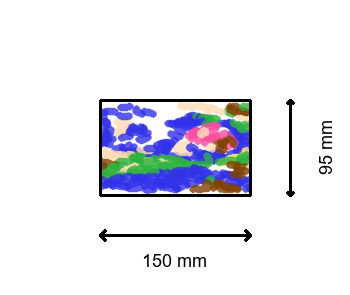

In [16]:
from visualisation import visualize_stroke_sequence
from datatypes import StrokeSequence
from tqdm import tqdm # progress bar
from stroke_generation import StrokeGenerationSupervisor

H, W, _ = np_resized_image.shape

stroke_sequence = StrokeSequence(image_size=(W, H))
coverage_mask = ~np_padded_mask_resized

# Sort the depth thresholds ascendingly to easily find the correct bracket
stroke_generation_supervisor = StrokeGenerationSupervisor()

# Loop through the targeted depth layer bins (Back-to-Front ordering)
for label, mean_depth in tqdm(segment_depths):
    ## Choose brush-size
    segment_mask = (resized_segments == label)
    if not np.any(segment_mask):
        continue

    ## Choose brush-size based on the pre-calculated brush_size_map
    # Extract the brush size assigned to this specific segment region
    chosen_brush_size = int(10 / 2) # int(np.max(brush_size_map[segment_mask]))
    
    # Dynamically assign it to the supervisor configuration for this layer
    stroke_generation_supervisor.brush_size = chosen_brush_size

    # Call the updated stroke generator function using dictionary unpacking (**)
    generate_strokes_for_layer(
        grad=(gy, gx),
        stroke_sequence=stroke_sequence, 
        resized_segments=resized_segments, 
        label=label, 
        image=np_resized_image,
        coverage_mask=coverage_mask,
        padding_mask=np_padded_mask_resized,
        stroke_generation_supervisor=stroke_generation_supervisor,
    )
    
visualize_stroke_sequence(stroke_sequence)

## Stroke Statistics
We counted the reason for a stroke to be declined.
Now, we will create a graph to visualize this.

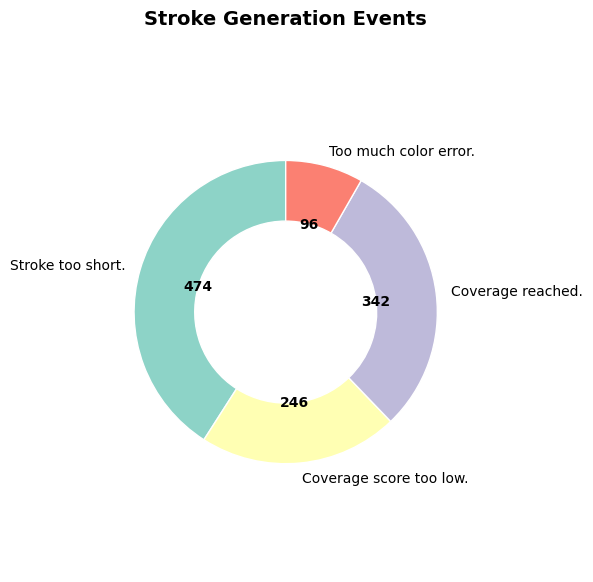

In [17]:
stroke_generation_supervisor.plot_decline_reasons()

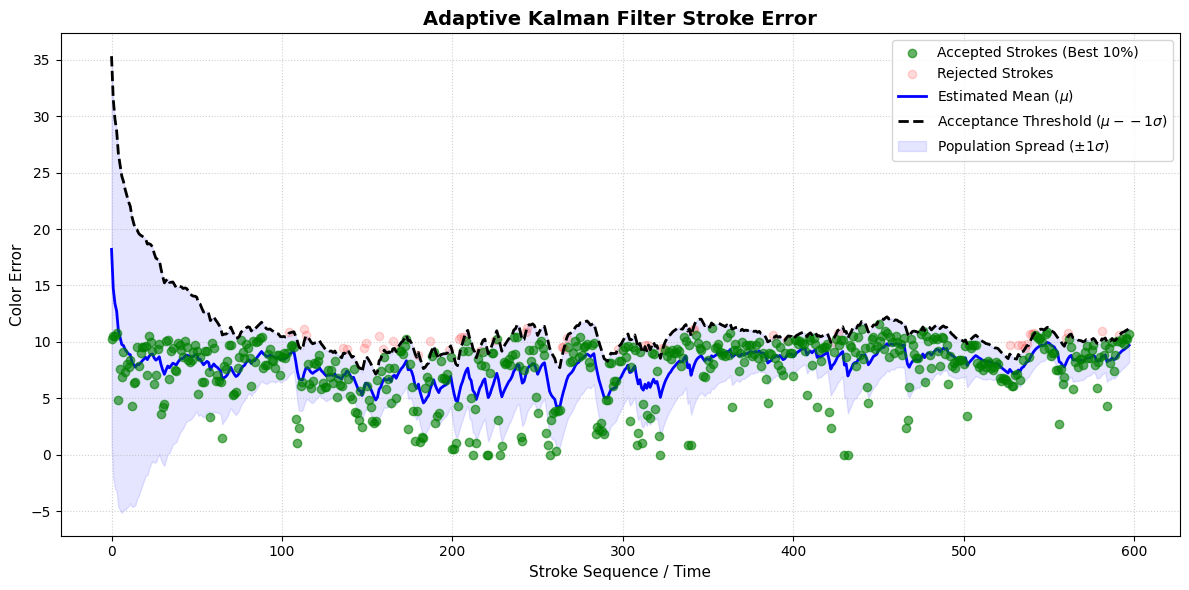

In [18]:
stroke_generation_supervisor.plot_color_error_history()

In [19]:
# order strokes
stroke_sequence.sort()

Create a video from the strokes.

In [20]:
from visualisation import animate_stroke_sequence

animate_stroke_sequence(stroke_sequence, filename="render")

Start video rendering...


100%|██████████| 230/230 [00:00<00:00, 271.93it/s]


Save the strokes to a json file.

In [21]:
stroke_sequence.save_to_json("data/my_stroke_sequence.json")